In [1]:
!wget -O banglaclip_model_epoch_10.pth https://huggingface.co/Mansuba/BanglaCLIP13/resolve/main/banglaclip_model_epoch_10.pth


--2025-01-23 12:01:17--  https://huggingface.co/Mansuba/BanglaCLIP13/resolve/main/banglaclip_model_epoch_10.pth
Resolving huggingface.co (huggingface.co)... 18.239.50.103, 18.239.50.49, 18.239.50.80, ...
Connecting to huggingface.co (huggingface.co)|18.239.50.103|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/2a/ad/2aadee49f0f0c86b7b267a72f0937b06e9c98f694b60f9d09a1698caad62340d/f25c01d0773579e603903fefc52f721337cf92cbcbfb4ab6e48d2c858c8cbc3f?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27banglaclip_model_epoch_10.pth%3B+filename%3D%22banglaclip_model_epoch_10.pth%22%3B&Expires=1737637277&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczNzYzNzI3N319LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zLzJhL2FkLzJhYWRlZTQ5ZjBmMGM4NmI3YjI2N2E3MmYwOTM3YjA2ZTljOThmNjk0YjYwZjlkMDlhMTY5OGNhYWQ2MjM0MGQvZjI1YzAxZDA3NzM1NzllNjAzOTAzZmVmYzUyZjcyMTMzN2NmOTJjYmNiZmI0YWI2Z

#fss fid score with banglaclip

<ipython-input-10-413c3fc42e04>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/content/banglaclip_model_epoch_10.pth", map_location=self.device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/50 [00:00<?, ?it/s]

<ipython-input-10-413c3fc42e04>:118: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  ref_tensor = torch.tensor(ref_features, dtype=torch.float32).to(self.device)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

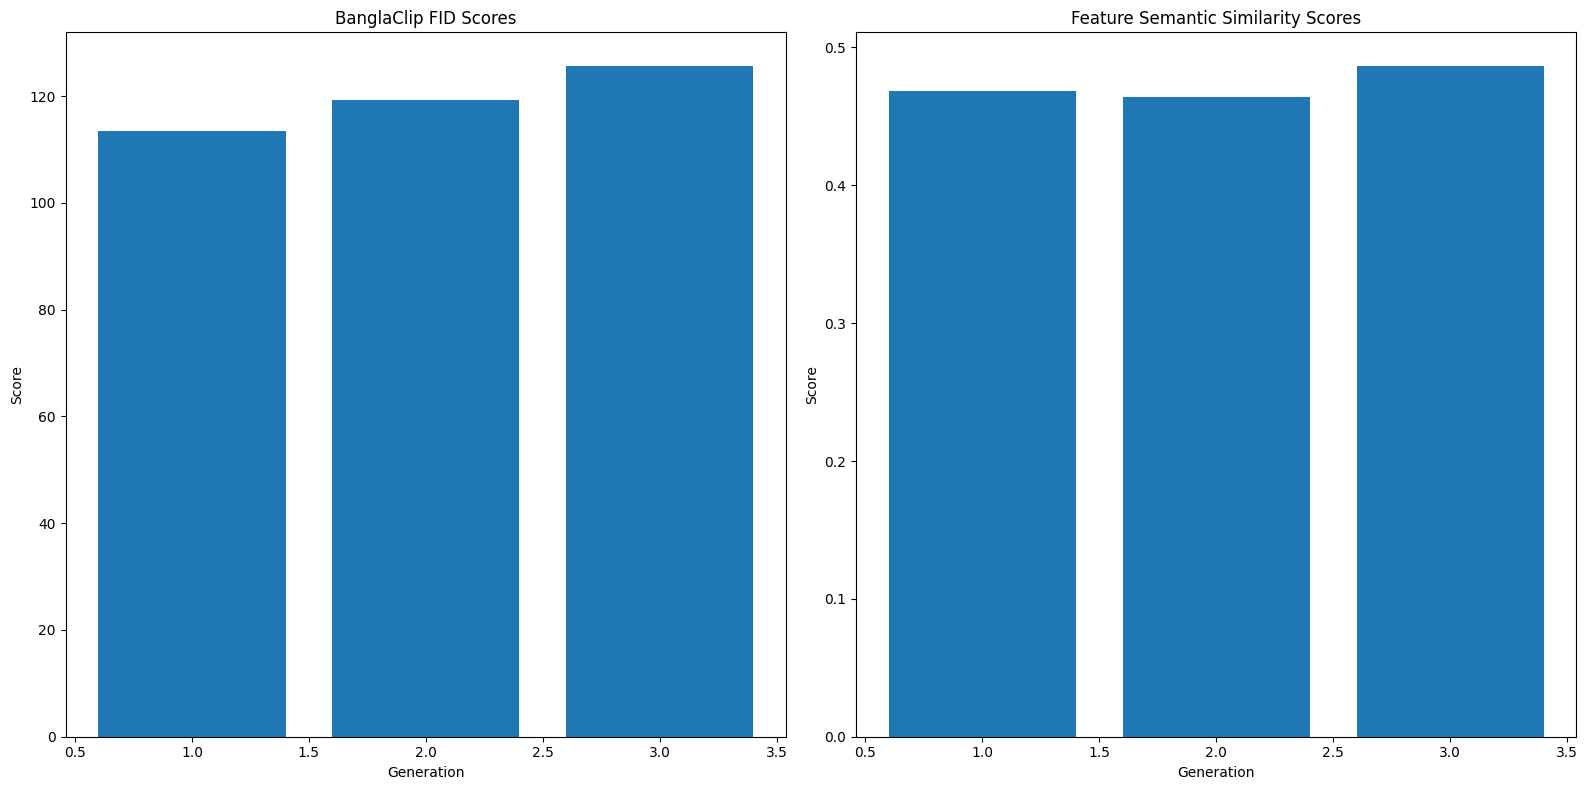

BanglaClip FID Metrics: [113.42310333251953, 119.16099548339844, 125.64574432373047]
Feature Semantic Similarity Scores: [0.4681099, 0.46395814, 0.4866482]


In [10]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from transformers import CLIPModel
from diffusers import StableDiffusionPipeline
import torch.nn as nn

class BanglaClipModel(torch.nn.Module):
    def __init__(self, num_classes):
        super(BanglaClipModel, self).__init__()
        self.clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.classifier = torch.nn.Linear(
            self.clip_model.text_model.config.hidden_size,
            num_classes
        )

class FeatureSemanticSimilarity(nn.Module):
    def __init__(self, feature_dim):
        super(FeatureSemanticSimilarity, self).__init__()
        self.fc1 = nn.Linear(feature_dim, feature_dim // 2)
        self.fc2 = nn.Linear(feature_dim // 2, 1)
        self.relu = nn.ReLU()

    def forward(self, features1, features2):
        # Concatenate features
        combined = torch.cat((features1, features2), dim=1)

        # Pass through layers
        x = self.relu(self.fc1(combined))
        similarity = torch.sigmoid(self.fc2(x))
        return similarity.squeeze()

class EnhancedImageMetricsEvaluator:
    def __init__(self, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.bangla_clip = BanglaClipModel(num_classes=10)

        try:
            checkpoint = torch.load("/content/banglaclip_model_epoch_10.pth", map_location=self.device)
            state_dict = checkpoint.get('model_state_dict', checkpoint) if isinstance(checkpoint, dict) else checkpoint
            self.bangla_clip.load_state_dict(state_dict, strict=False)
        except Exception as e:
            print(f"Error loading BanglaClip model: {e}")
            print("Falling back to standard OpenAI CLIP model")

        self.bangla_clip.eval().to(self.device)

        self.resnet_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.pipeline = StableDiffusionPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            safety_checker=None
        ).to(self.device)

        # Initialize Feature Semantic Similarity module
        self.fss_module = FeatureSemanticSimilarity(feature_dim=512*2).to(self.device)

    def _safe_fid_calculation(self, mu1, sigma1, mu2, sigma2):
        """Robust FID calculation with error handling"""
        try:
            # Ensure inputs are at least 2D
            mu1 = np.atleast_2d(mu1.flatten())
            mu2 = np.atleast_2d(mu2.flatten())

            # Ensure covariance matrices are 2D
            sigma1 = np.atleast_2d(sigma1)
            sigma2 = np.atleast_2d(sigma2)

            # Ensure symmetric covariance matrices
            sigma1 = (sigma1 + sigma1.T) / 2
            sigma2 = (sigma2 + sigma2.T) / 2

            # Compute matrix square root
            try:
                covmean = sqrtm(sigma1.dot(sigma2))
            except:
                # Fallback method if sqrtm fails
                covmean = np.eye(sigma1.shape[0])

            # Handle complex numbers
            if np.iscomplexobj(covmean):
                covmean = covmean.real

            # Calculate FID
            diff = mu1.flatten() - mu2.flatten()
            fid = np.sum(diff**2) + np.trace(sigma1 + sigma2 - 2 * covmean)

            return float(fid)
        except Exception as e:
            print(f"Robust FID Calculation Error: {e}")
            return float('inf')

    def _compute_statistics(self, features):
        """Compute mean and covariance, handling single sample"""
        features = np.atleast_2d(features)
        mu = np.mean(features, axis=0)
        sigma = np.cov(features, rowvar=False) if features.shape[0] > 1 else np.eye(features.shape[1])
        return mu, sigma

    def calculate_fid(self, ref_features, gen_features):
        """Wrapper for FID calculation with robust statistics"""
        mu1, sigma1 = self._compute_statistics(ref_features)
        mu2, sigma2 = self._compute_statistics(gen_features)
        return self._safe_fid_calculation(mu1, sigma1, mu2, sigma2)

    def calculate_fss(self, ref_features, gen_features):
        """Calculate Feature Semantic Similarity"""
        ref_tensor = torch.tensor(ref_features, dtype=torch.float32).to(self.device)
        gen_tensor = torch.tensor(gen_features, dtype=torch.float32).to(self.device)

        with torch.no_grad():
            similarities = []
            for ref_feat in ref_tensor:
                for gen_feat in gen_tensor:
                    similarity = self.fss_module(ref_feat.unsqueeze(0), gen_feat.unsqueeze(0)).cpu().numpy()
                    similarities.append(similarity)

        return np.mean(similarities)

    def extract_bangla_clip_features(self, image: Image.Image) -> np.ndarray:
        image_tensor = self.resnet_transform(image).unsqueeze(0).to(self.device)
        with torch.no_grad():
            image_features = self.bangla_clip.clip_model.get_image_features(image_tensor)
            return image_features.cpu().numpy().squeeze()

    def evaluate_images(self, reference_images: list, prompt: str, num_generations: int = 3):
        # Extract reference features
        bangla_clip_ref_features = [self.extract_bangla_clip_features(img) for img in reference_images]

        # Results storage
        results = {
            'bangla_clip_fid': [],
            'fss_score': [],
            'generated_images': []
        }

        # Generate and evaluate images
        for _ in range(num_generations):
            # Generate image
            generated_image = self.pipeline(prompt=prompt).images[0]
            results['generated_images'].append(generated_image)

            # Extract generated features
            bangla_clip_gen_features = self.extract_bangla_clip_features(generated_image)

            # Calculate FID for BanglaClip feature space
            results['bangla_clip_fid'].append(self.calculate_fid(
                bangla_clip_ref_features, [bangla_clip_gen_features]
            ))

            # Calculate Feature Semantic Similarity
            results['fss_score'].append(self.calculate_fss(
                bangla_clip_ref_features, [bangla_clip_gen_features]
            ))

        # Visualization
        plt.figure(figsize=(16, 8))
        metrics = ['BanglaClip FID', 'Feature Semantic Similarity']
        scores = [
            results['bangla_clip_fid'],
            results['fss_score']
        ]

        for i, (metric, scores_list) in enumerate(zip(metrics, scores), 1):
            plt.subplot(1, 2, i)
            plt.bar(range(1, num_generations + 1), scores_list)
            plt.title(f'{metric} Scores')
            plt.xlabel('Generation')
            plt.ylabel('Score')

        plt.tight_layout()
        plt.show()

        return results

# Example usage
if __name__ == "__main__":
    reference_images = [
        Image.open("/content/348858663-b59cfff8-4c2d-449d-8eec-1bf9904abd2f.png")
    ]

    prompt = "একটি নীল টি-শার্ট পরা একটি মেয়ে"

    evaluator = EnhancedImageMetricsEvaluator()
    results = evaluator.evaluate_images(reference_images, prompt)

    # Print metrics
    print("BanglaClip FID Metrics:", results['bangla_clip_fid'])
    print("Feature Semantic Similarity Scores:", results['fss_score'])